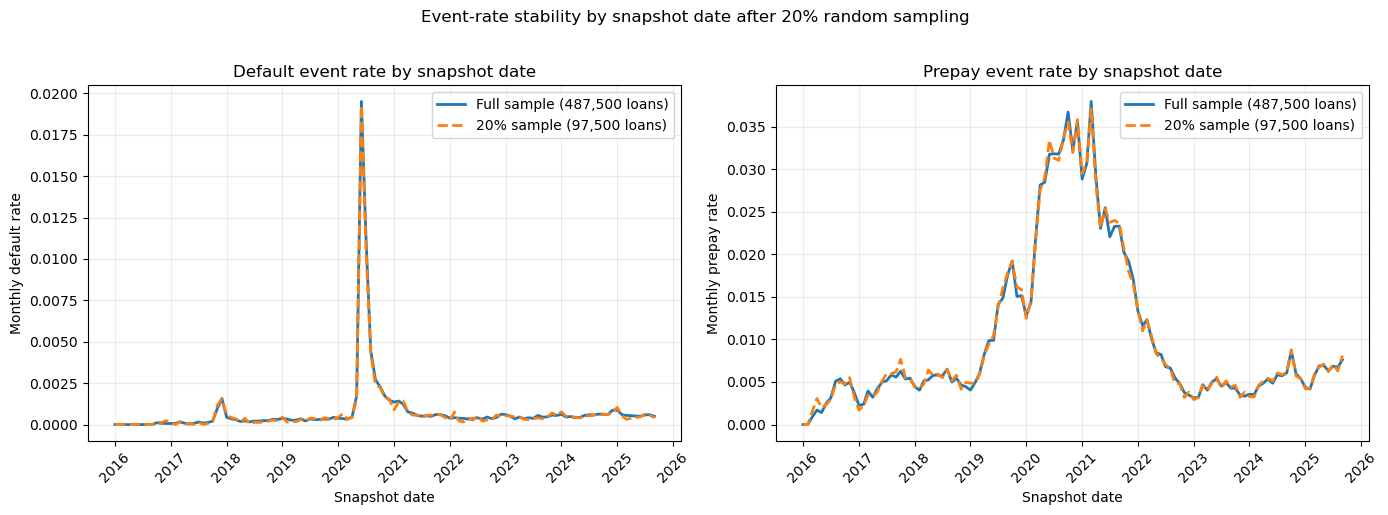

Original loans: 487,500
Sampled loans:  97,500 (20%)
Overall default rate  | full = 0.000860, sample = 0.000823
Overall prepay rate   | full = 0.010655, sample = 0.010687
Exported default sample rows: 3,570,337
Exported prepay sample rows:  3,570,337
Default sample path: /Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage/panel_default_modeling_2016_2025_sample20_seed66.parquet
Prepay sample path:  /Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage/panel_prepay_modeling_2016_2025_sample20_seed66.parquet


In [5]:
# Evaluate whether 20% random sampling by loan_id preserves event patterns
# and export sampled panels with all variables for downstream modeling.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from pathlib import Path

OUTDIR = Path("/Users/jinyecai/Desktop/ML_Mortgage/processed_mortgage")
panelD_path = OUTDIR / "panel_default_modeling_2016_2025.parquet"
panelP_path = OUTDIR / "panel_prepay_modeling_2016_2025.parquet"

sample_frac = 0.20
random_seed = 66
sample_tag = f"sample{int(sample_frac * 100):02d}_seed{random_seed}"

default_sample_path = OUTDIR / f"panel_default_modeling_2016_2025_{sample_tag}.parquet"
prepay_sample_path = OUTDIR / f"panel_prepay_modeling_2016_2025_{sample_tag}.parquet"

# Read only the columns needed for the event-rate comparison.
dfD_rate = pd.read_parquet(panelD_path, columns=["loan_id", "monthly_reporting_period", "y_default"])
dfP_rate = pd.read_parquet(panelP_path, columns=["loan_id", "monthly_reporting_period", "y_prepay"])

all_loan_ids = pd.Index(dfD_rate["loan_id"].unique())
rng = np.random.default_rng(random_seed)
sample_n = int(len(all_loan_ids) * sample_frac)
sampled_loan_ids = pd.Index(rng.choice(all_loan_ids.to_numpy(), size=sample_n, replace=False))

dfD_rate_sample = dfD_rate[dfD_rate["loan_id"].isin(sampled_loan_ids)].copy()
dfP_rate_sample = dfP_rate[dfP_rate["loan_id"].isin(sampled_loan_ids)].copy()

def event_rate_by_snapshotdate(df, event_col):
    out = (
        df.assign(snapshotdate=lambda x: pd.to_datetime(x["monthly_reporting_period"], format="%Y%m", errors="coerce"))
        .dropna(subset=["snapshotdate"])
        .groupby("snapshotdate", as_index=False)[event_col]
        .mean()
        .sort_values("snapshotdate")
    )
    return out

def export_full_sample(src_path, sampled_ids, out_path):
    dataset = ds.dataset(src_path, format="parquet")
    filter_expr = ds.field("loan_id").isin(sampled_ids.tolist())
    scanner = dataset.scanner(filter=filter_expr)

    writer = None
    rows_written = 0
    try:
        for batch in scanner.to_batches():
            batch_table = pa.Table.from_batches([batch])
            if writer is None:
                writer = pq.ParquetWriter(out_path, batch_table.schema)
            writer.write_table(batch_table)
            rows_written += batch.num_rows
    finally:
        if writer is not None:
            writer.close()

    return rows_written

default_rows = export_full_sample(panelD_path, sampled_loan_ids, default_sample_path)
prepay_rows = export_full_sample(panelP_path, sampled_loan_ids, prepay_sample_path)

default_full = event_rate_by_snapshotdate(dfD_rate, "y_default")
default_sample = event_rate_by_snapshotdate(dfD_rate_sample, "y_default")
prepay_full = event_rate_by_snapshotdate(dfP_rate, "y_prepay")
prepay_sample = event_rate_by_snapshotdate(dfP_rate_sample, "y_prepay")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(
    default_full["snapshotdate"],
    default_full["y_default"],
    label=f"Full sample ({dfD_rate['loan_id'].nunique():,} loans)",
    color="tab:blue",
    linewidth=2,
)
axes[0].plot(
    default_sample["snapshotdate"],
    default_sample["y_default"],
    label=f"20% sample ({dfD_rate_sample['loan_id'].nunique():,} loans)",
    color="tab:orange",
    linewidth=2,
    linestyle="--",
)
axes[0].set_title("Default event rate by snapshot date")
axes[0].set_xlabel("Snapshot date")
axes[0].set_ylabel("Monthly default rate")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    prepay_full["snapshotdate"],
    prepay_full["y_prepay"],
    label=f"Full sample ({dfP_rate['loan_id'].nunique():,} loans)",
    color="tab:blue",
    linewidth=2,
)
axes[1].plot(
    prepay_sample["snapshotdate"],
    prepay_sample["y_prepay"],
    label=f"20% sample ({dfP_rate_sample['loan_id'].nunique():,} loans)",
    color="tab:orange",
    linewidth=2,
    linestyle="--",
)
axes[1].set_title("Prepay event rate by snapshot date")
axes[1].set_xlabel("Snapshot date")
axes[1].set_ylabel("Monthly prepay rate")
axes[1].grid(alpha=0.25)
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Event-rate stability by snapshot date after 20% random sampling", y=1.02)
plt.tight_layout()
plt.show()

print(f"Original loans: {len(all_loan_ids):,}")
print(f"Sampled loans:  {len(sampled_loan_ids):,} ({sample_frac:.0%})")
print(f"Overall default rate  | full = {dfD_rate['y_default'].mean():.6f}, sample = {dfD_rate_sample['y_default'].mean():.6f}")
print(f"Overall prepay rate   | full = {dfP_rate['y_prepay'].mean():.6f}, sample = {dfP_rate_sample['y_prepay'].mean():.6f}")
print(f"Exported default sample rows: {default_rows:,}")
print(f"Exported prepay sample rows:  {prepay_rows:,}")
print(f"Default sample path: {default_sample_path}")
print(f"Prepay sample path:  {prepay_sample_path}")

# Merge Macro Data

- pulls FRED series from API
- reads local Freddie PMMS Excel
- reads local FHFA state HPI CSV
- reads local AQI county files and collapses them to `state-year median(Median AQI)`
- merges everything into the default or prepay modeling panel

Notes:
- `PMMS` is weekly, so it is averaged to month
- `FHFA state HPI` is quarterly, so each quarter value is copied to the 3 months in that quarter
- `AQI` is county-year, but your panel does not have county, so it is aggregated to `state-year`, `Median AQI` is merged to panel.

In [6]:
import os
from pathlib import Path

import pandas as pd
import requests

ROOT = Path('/Users/jinyecai/Desktop/ML_Mortgage')
PROC = ROOT / 'processed_mortgage'
MACRO = PROC / 'macro_raw'
AQI_DIR = PROC / 'AQI'
OUTDIR = PROC / 'macro_merged'

PANEL_PATHS = {
    'default': PROC / 'panel_default_modeling_2016_2025_sample20_seed66.parquet',
    'prepay': PROC / 'panel_prepay_modeling_2016_2025_sample20_seed66.parquet',
}

PMMS_PATH = MACRO / 'freddie_pmms' / 'pmms_rates.xlsx'
FHFA_PATH = MACRO / 'fhfa' / 'fha_hpi_master.csv'

FRED_API_KEY = os.getenv('FRED_API_KEY', '')
FRED_SERIES = {
    'UNRATE': 'unrate',
    'CPIAUCSL': 'cpi',
    'FEDFUNDS': 'fedfunds',
    'GS10': 'gs10',
}

STATE_ABBR = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR', 'CALIFORNIA': 'CA',
    'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE', 'DISTRICT OF COLUMBIA': 'DC',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID', 'ILLINOIS': 'IL',
    'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS', 'KENTUCKY': 'KY', 'LOUISIANA': 'LA',
    'MAINE': 'ME', 'MARYLAND': 'MD', 'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN',
    'MISSISSIPPI': 'MS', 'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK', 'OREGON': 'OR',
    'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD',
    'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT', 'VERMONT': 'VT', 'VIRGINIA': 'VA',
    'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV', 'WISCONSIN': 'WI', 'WYOMING': 'WY'
}


def to_yyyymm(date_series):
    dt = pd.to_datetime(date_series)
    return dt.dt.year * 100 + dt.dt.month


def load_panel(kind='default'):
    return pd.read_parquet(PANEL_PATHS[kind]).copy()


def get_fred_series(series_id, api_key=FRED_API_KEY):
    url = 'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json'
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    df = pd.DataFrame(r.json()['observations'])[['date', 'value']].copy()
    df['value'] = pd.to_numeric(df['value'].replace('.', pd.NA), errors='coerce')
    df['rp_yyyymm'] = to_yyyymm(df['date'])
    return df.groupby('rp_yyyymm', as_index=False)['value'].last()


def load_fred_bundle(api_key=FRED_API_KEY):
    out = None
    for series_id, name in FRED_SERIES.items():
        df = get_fred_series(series_id, api_key=api_key).rename(columns={'value': name})
        out = df if out is None else out.merge(df, on='rp_yyyymm', how='outer')
    out = out.sort_values('rp_yyyymm').reset_index(drop=True)
    out['cpi_yoy'] = out['cpi'].pct_change(12)
    return out


def load_pmms():
    df = pd.read_excel(PMMS_PATH, header=5)
    df = df.rename(columns={'Unnamed: 0': 'week', '30 yr': 'pmms30'})
    df = df[['week', 'pmms30']].copy()
    df['week'] = pd.to_datetime(df['week'], errors='coerce', format='mixed')
    df = df.dropna(subset=['week']).copy()
    df['pmms30'] = pd.to_numeric(df['pmms30'], errors='coerce')
    df['rp_yyyymm'] = to_yyyymm(df['week'])
    return df.groupby('rp_yyyymm', as_index=False)['pmms30'].mean()


def load_fhfa_state_hpi():
    df = pd.read_csv(FHFA_PATH, low_memory=False)
    df = df[(df['level'] == 'State') & (df['frequency'] == 'quarterly') & (df['hpi_flavor'] == 'purchase-only')].copy()
    df['property_state'] = df['place_name'].str.upper().map(STATE_ABBR)
    quarter_months = {1: [1, 2, 3], 2: [4, 5, 6], 3: [7, 8, 9], 4: [10, 11, 12]}
    rows = []
    for _, r in df[['property_state', 'yr', 'period', 'index_nsa']].dropna().iterrows():
        for m in quarter_months[int(r['period'])]:
            rows.append({
                'property_state': r['property_state'],
                'rp_yyyymm': int(r['yr']) * 100 + m,
                'fhfa_hpi': r['index_nsa']
            })
    out = pd.DataFrame(rows)
    out = out.sort_values(['property_state', 'rp_yyyymm']).reset_index(drop=True)
    out['fhfa_hpi_yoy'] = out.groupby('property_state')['fhfa_hpi'].pct_change(12)
    return out


def load_aqi_state_year():
    files = sorted(AQI_DIR.glob('annual_aqi_by_county_*.csv'))
    parts = [pd.read_csv(f, usecols=['State', 'Year', 'Median AQI']) for f in files]
    df = pd.concat(parts, ignore_index=True)
    df['property_state'] = df['State'].str.upper().map(STATE_ABBR)
    out = (
        df.groupby(['property_state', 'Year'], as_index=False)['Median AQI']
          .median()
          .rename(columns={'Year': 'year', 'Median AQI': 'median_aqi'})
    )
    return out


def merge_macro(kind='default', api_key=FRED_API_KEY, save=False):
    panel = load_panel(kind)
    panel['year'] = panel['rp_yyyymm'] // 100

    fred = load_fred_bundle(api_key)
    pmms = load_pmms()
    hpi = load_fhfa_state_hpi()
    aqi = load_aqi_state_year()

    out = panel.merge(fred, on='rp_yyyymm', how='left')
    out = out.merge(pmms, on='rp_yyyymm', how='left')
    out = out.merge(hpi, on=['property_state', 'rp_yyyymm'], how='left')
    out = out.merge(aqi, on=['property_state', 'year'], how='left')
    out['mortgage_treasury_spread'] = out['pmms30'] - out['gs10']

    save_path = None
    if save:
        OUTDIR.mkdir(parents=True, exist_ok=True)
        save_path = OUTDIR / f'panel_{kind}_with_macro.parquet'
        out.to_parquet(save_path, index=False)

    return out, save_path


FRED_API_KEY = "501431dcdd4d89dc0547ab37ac6ac7e2"
# default_macro, _ = merge_macro('default', api_key=FRED_API_KEY)
# prepay_macro, _ = merge_macro('prepay', api_key=FRED_API_KEY)
default_macro, default_path = merge_macro('default', api_key=FRED_API_KEY, save=True)
prepay_macro, prepay_path = merge_macro('prepay', api_key=FRED_API_KEY, save=True)

# Quick checks
default_macro[['rp_yyyymm', 'property_state', 'unrate', 'pmms30', 'fhfa_hpi', 'median_aqi']].head()
default_macro[['unrate', 'cpi', 'fedfunds', 'gs10', 'pmms30', 'fhfa_hpi', 'median_aqi']].isna().mean().sort_values()


/var/folders/zk/lmw40k6550g71ccqbjlkfnjw0000gn/T/ipykernel_2110/4195341348.py:74: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out['cpi_yoy'] = out['cpi'].pct_change(12)
/var/folders/zk/lmw40k6550g71ccqbjlkfnjw0000gn/T/ipykernel_2110/4195341348.py:74: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out['cpi_yoy'] = out['cpi'].pct_change(12)


unrate        0.000000
cpi           0.000000
fedfunds      0.000000
gs10          0.000000
pmms30        0.000000
fhfa_hpi      0.000395
median_aqi    0.000395
dtype: float64

In [12]:
default_macro[['rp_yyyymm', 'property_state', 'unrate', 'pmms30', 'fhfa_hpi', 'median_aqi']].loc[default_macro['rp_yyyymm'] == 201601]


,rp_yyyymm,property_state,unrate,pmms30,fhfa_hpi,median_aqi
2051,201601,OH,4.8,3.8725,167.34,43.0
3087,201601,WA,4.8,3.8725,276.77,28.0
8557,201601,IL,4.8,3.8725,177.94,42.0
17877,201601,IL,4.8,3.8725,177.94,42.0
25233,201601,TX,4.8,3.8725,240.97,40.0


In [14]:
default_macro.columns

Index(['loan_sequence_number', 'monthly_reporting_period', 'rp_yyyymm',
       'file_year_x', 'loan_id', 'loan_age',
       'remaining_months_to_legal_maturity', 'current_actual_upb',
       'interest_bearing_upb', 'current_interest_rate',
       'estimated_loan_to_value_eltv', 'modification_flag', 'y_default',
       'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date',
       'metropolitan_statistical_area_msa_or_metropolitan_division',
       'mortgage_insurance_percentage_mi_pct', 'number_of_units',
       'occupancy_status', 'original_combined_loan_to_value_cltv',
       'original_debt_to_income_dti_ratio', 'original_upb',
       'original_loan_to_value_ltv', 'original_interest_rate', 'channel',
       'prepayment_penalty_mortgage_ppm_flag',
       'amortization_type_formerly_product_type', 'property_state',
       'property_type', 'postal_code', 'loan_purpose', 'original_loan_term',
       'number_of_borrowers', 'seller_name', 'servicer_name',